In [0]:
%python
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


In [0]:

df = pd.read_csv('/Workspace/Users/labuser11105938_1754643157@vocareum.com/housing_data_cleaned_STD.csv')

In [0]:

#Data Familiarisation

print(df.info())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19680 entries, 0 to 19679
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      19680 non-null  float64
 1   HouseAge    19680 non-null  float64
 2   AveRooms    19680 non-null  float64
 3   AveBedrms   19680 non-null  float64
 4   Population  19680 non-null  float64
 5   AveOccup    19680 non-null  float64
 6   Latitude    19680 non-null  float64
 7   Longitude   19680 non-null  float64
 8   Target      19680 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [0]:
# Distrubution Features
print(df.describe())

             MedInc      HouseAge  ...     Longitude        Target
count  19680.000000  19680.000000  ...  19680.000000  19680.000000
mean       3.732032     28.977337  ...   -119.581786      2.025882
std        1.605051     12.449452  ...      2.004602      1.108107
min        0.499900      1.000000  ...   -124.350000      0.149990
25%        2.543000     19.000000  ...   -121.800000      1.183000
50%        3.500000     29.000000  ...   -118.500000      1.780000
75%        4.659325     37.000000  ...   -118.020000      2.603000
max        9.556100     52.000000  ...   -114.550000      5.000010

[8 rows x 9 columns]


In [0]:
# IS NULL CHECK
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64


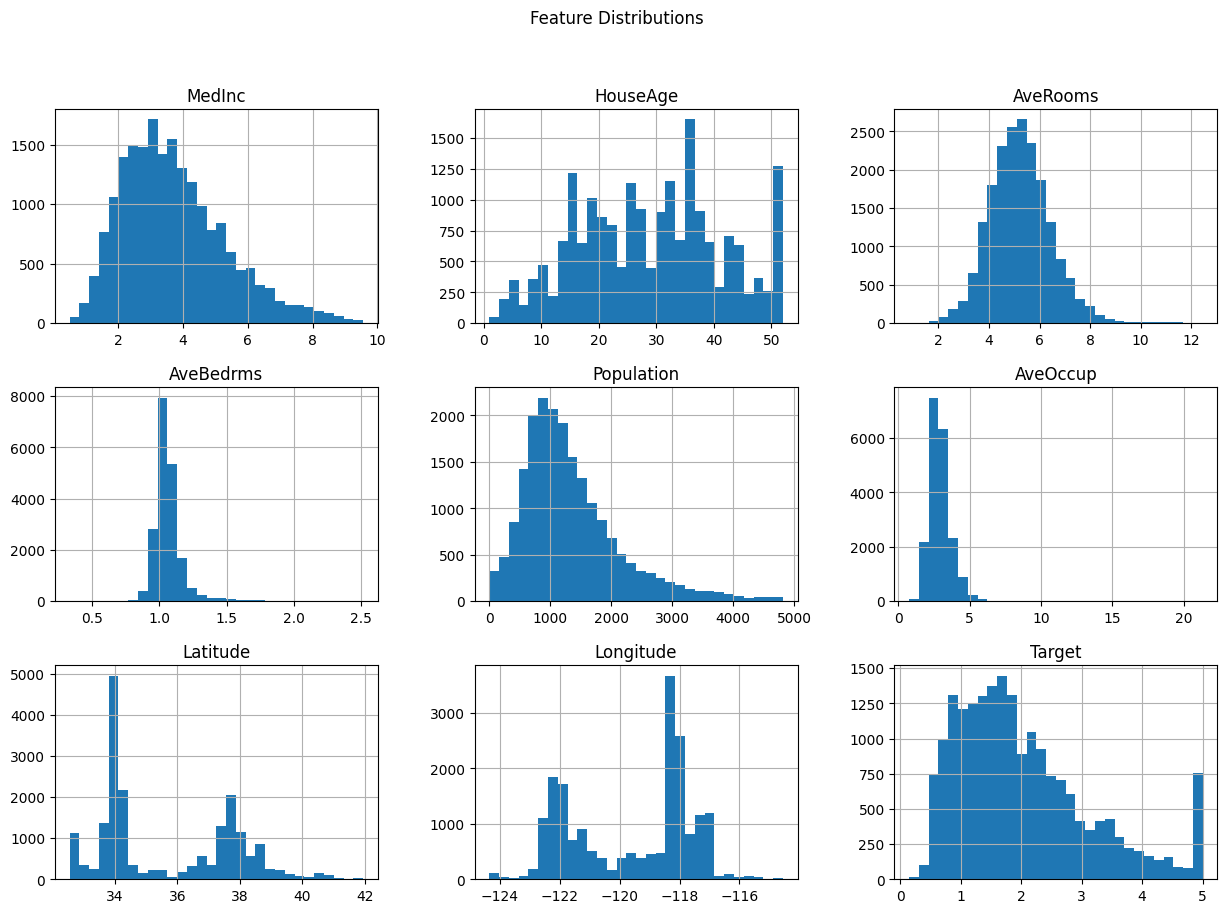

In [0]:
# Distribution of features - histograms
df.hist(bins=30, figsize=(15,10))
plt.suptitle('Feature Distributions')
plt.show()

In [0]:
correlations = df.corr()['Target'].drop('Target').sort_values(ascending=False)
print(correlations)

MedInc        0.658571
AveRooms      0.255375
HouseAge      0.111955
Population   -0.023895
Longitude    -0.045789
AveBedrms    -0.091734
Latitude     -0.145059
AveOccup     -0.261275
Name: Target, dtype: float64


In [0]:
# Drop rows with missing values in selected feature or target
df_clean = df[['MedInc', 'Target']].dropna()

In [0]:
# Linear Regression model fitting
 
X = df_clean[['MedInc']] 
y = df_clean['Target']   

In [0]:
model = LinearRegression()
model.fit(X, y)
 
# Coefficients
print(f"Intercept: {model.intercept_}")
print(f"Coefficient for MedInc: {model.coef_[0]}")

Intercept: 0.32904223137259025
Coefficient for MedInc: 0.4546689786464669


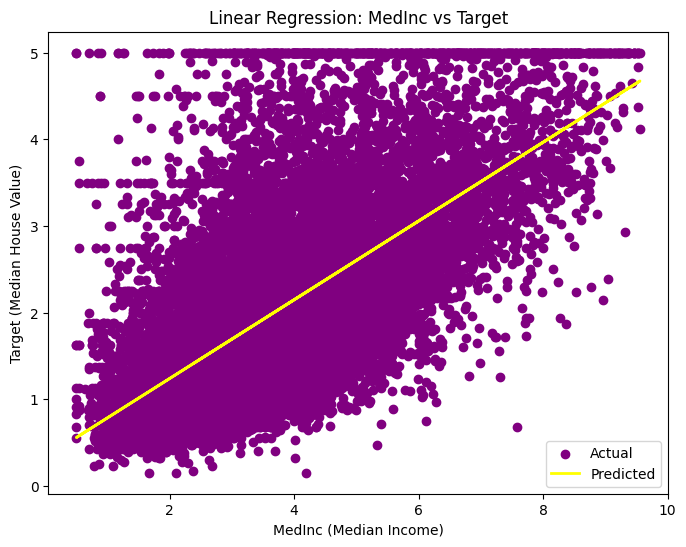

In [0]:
# Prediction and scatter plot
 
y_pred = model.predict(X)
 
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='purple', label='Actual')
plt.plot(X, y_pred, color='yellow', linewidth=2, label='Predicted')
plt.xlabel('MedInc (Median Income)')
plt.ylabel('Target (Median House Value)')
plt.title('Linear Regression: MedInc vs Target')
plt.legend()
plt.show()

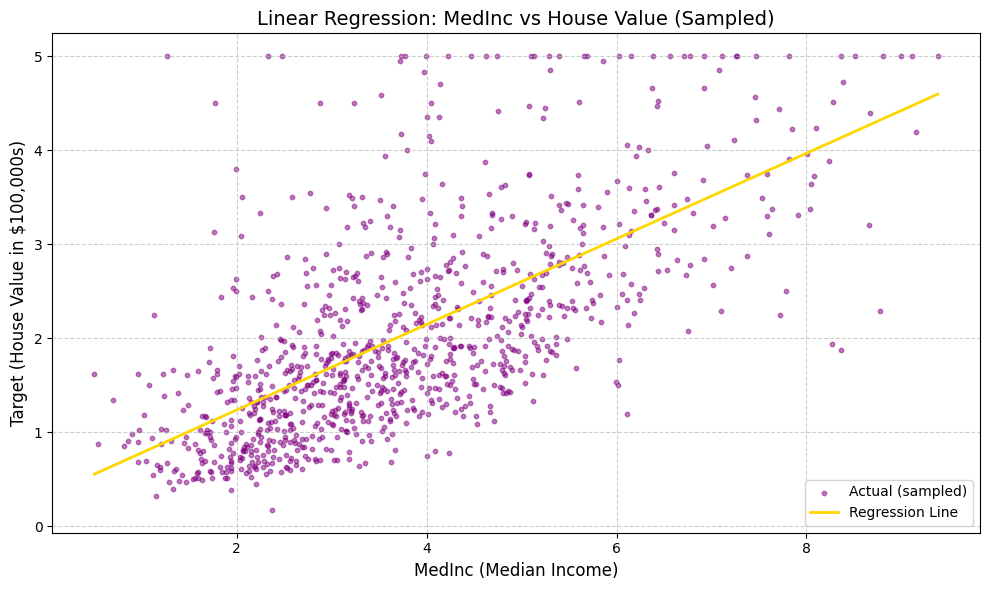

In [0]:
# Sample 1000 points randomly for plotting
df_sampled = df_clean.sample(n=1000, random_state=42)

X_sampled = df_sampled[['MedInc']]
y_sampled = df_sampled['Target']
y_pred_sampled = model.predict(X_sampled)

# Sort for line plotting
sorted_idx = X_sampled['MedInc'].argsort()
X_sorted = X_sampled.iloc[sorted_idx]
y_pred_sorted = y_pred_sampled[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_sampled, y_sampled, color='purple', s=10, alpha=0.5, label='Actual (sampled)')
plt.plot(X_sorted, y_pred_sorted, color='gold', linewidth=2, label='Regression Line')
plt.xlabel('MedInc (Median Income)', fontsize=12)
plt.ylabel('Target (House Value in $100,000s)', fontsize=12)
plt.title('Linear Regression: MedInc vs House Value (Sampled)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


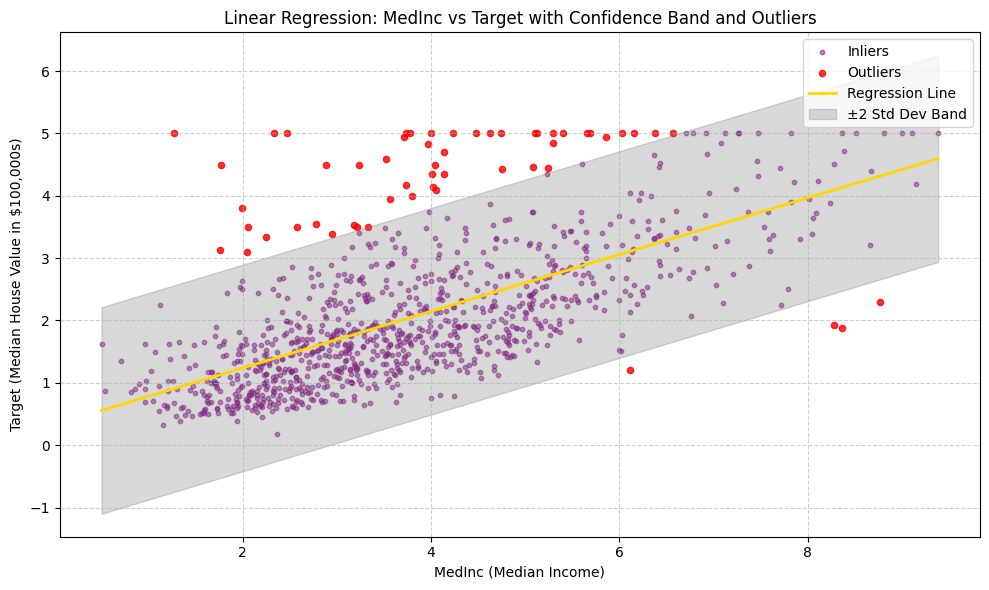

In [0]:
X_sampled = df_sampled[['MedInc']]
y_sampled = df_sampled['Target']

# Predict on sampled data
y_pred_sampled = model.predict(X_sampled)

# Sort for line and band plotting
sorted_idx = X_sampled['MedInc'].argsort()
X_sorted = X_sampled.iloc[sorted_idx]
y_pred_sorted = y_pred_sampled[sorted_idx]

# Calculate residuals and their standard deviation
residuals = y_sampled - y_pred_sampled
residual_std = np.std(residuals)

# Define upper and lower bounds for the confidence band
upper_band = y_pred_sorted + 2 * residual_std
lower_band = y_pred_sorted - 2 * residual_std

# Identify outliers outside the band
outliers_mask = (y_sampled < (y_pred_sampled - 2 * residual_std)) | (y_sampled > (y_pred_sampled + 2 * residual_std))


plt.figure(figsize=(10, 6))
plt.scatter(X_sampled.loc[~outliers_mask, 'MedInc'], y_sampled.loc[~outliers_mask], s=10, alpha=0.5, label='Inliers', color='purple')

# Outliers
plt.scatter(X_sampled.loc[outliers_mask, 'MedInc'], y_sampled.loc[outliers_mask], s=20, alpha=0.8, label='Outliers', color='red')

plt.plot(X_sorted, y_pred_sorted, color='gold', linewidth=2, label='Regression Line')

# Confidence Band
plt.fill_between(X_sorted['MedInc'], lower_band, upper_band, color='grey', alpha=0.3, label='±2 Std Dev Band')

plt.xlabel('MedInc (Median Income)')
plt.ylabel('Target (Median House Value in $100,000s)')
plt.title('Linear Regression: MedInc vs Target with Confidence Band and Outliers')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
